#### segmentation : 이미지에서 특정 영역 분리

<span style="font-size:11px">

#### ▶ Gaussian Noise (가우스 노이즈)

1. 개념
- 가우스 노이즈는 이미지나 신호에 자연스럽게 발생하는 **무작위 잡음**의 한 종류예요.
- 통계에서 **정규분포(Normal distribution)**를 따르는 잡음이에요.
- 픽셀 값에 이 잡음을 더하면, 실제 센서에서 찍은 사진처럼 **약간 흐리거나 점 찍힌 것 같은 효과**가 나타나요.

2. 왜 사용하나?
- 데이터 증강 (Data Augmentation)
    - Segmentation 모델 학습 시, 다양한 환경에서 강인한 모델을 만들기 위해 일부러 노이즈를 넣음
- 모델 테스트
    - 모델이 노이즈가 있는 실제 환경에서도 잘 작동하는지 확인


In [13]:
# 가우스 잡음 추가 함수
import matplotlib.pyplot as plt
import numpy as np
import torch

from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor

# 가우스 노이즈
# noise_pixel = original_pixel + N(u=0, e = scale)
# 평균 = 0 : 픽셀을 전체적으로 밝히거나 어둡게 하지 않음
# 표준편차 = scale : 값이 클수록 노이즈가 강해짐
# scale=0.8 --> 노이즈의 양이 많고, 숫자일부를 흐릿 (클수록 안좋음?)

In [14]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# 하기 이미지셀 관련 커널 충돌로 인해 추가함

In [59]:
training_data = MNIST(root='data/', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='data/', train=False, download=True, transform=ToTensor())


C:\Users\playdata2\AppData\Local\Temp\ipykernel_14076\145963766.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gaussian_data_x = x + np.random.normal(
C:\Users\playdata2\AppData\Local\Temp\ipykernel_14076\145963766.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)


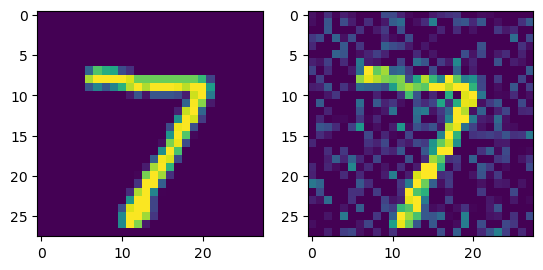

In [ ]:
img,label = next (iter(training_data))
gaussian = gaussian_noise(img, scale=0.2) #scale 을 변경해서 noise 조절
# gaussian
# plt에 넣기 위해서 순서 변경
img = img.permute(1,2,0)
gaussian = gaussian.permute(1,2,0)

plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(gaussian)

##=====> 실제 사진은 컬러아님!!!!!! 원래 흑백

In [ ]:
########## 실행1

def gaussian_noise(x, scale=0.8): # scale 값이 클수록 더 강한 노이즈 (거칠게 변함)
    
    # 원본데이터 x에 정규분포(가우스분포)를 따르는 랜덤 noise를 더함
    # 원래 이미지 + 무작위 생성된 가우스 노이즈 = 노이즈가 낀 이미지
        # loc=0 :  평균 : 잡음의 중심값이 0 → 전체적으로 밝기가 변하지 않음
        # scale=scale=0.8 : 표준편차 : 잡음의 세기 조절 (값이 클수록 노이즈 심함)
        # size=x.shape : 생성할 노이즈 크기 : 원본이미지와 같은 크기의 노이즈를 생성
    gaussian_data_x = x + np.random.normal(loc=0, scale=scale, size=x.shape)
    
    gaussian_data_x = np.clip(gaussian_data_x, 0, 1)  # 이미지픽셀의 값을 0과 1 사이로 자르는 과정
    gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)

    return gaussian_data_x


# 학습용 데이터넷
from torch.utils.data.dataset import Dataset

# 데이터셋(Denoise)은 “입력은 노이즈가 낀 이미지”, “정답은 깨끗한 원본 이미지”가 되도록 만들어진 클래스예요.
# Denoise : 0~9 숫자로 이루어져있음.
class Denoise(Dataset):
    def __init__(self):
        self.mnist=MNIST(root='data/', train=True, download=True, transform=ToTensor())
        self.data = []

        # 잡음 입히기
        for data, label in self.mnist:  #training data : tensor 여부와 사이즈 확인하기
            noise = gaussian_noise (data) 
            self.data.append(noise) 

    def __len__(self):   #데이터셋 전체 샘플 수 반환 (필수)
        return len(self.data)
    
    def __getitem__(self, index):  #인덱스로 개별 샘플 반환 (필수)
        data = self.data[index]
        label = self.mnist.data[index] / 255 # 255(RGB) 원본이미지도 0~1로 정규화
        return data, label

In [19]:
#training data : tensor 여부와 사이즈 확인하기
for data, label in training_data:
    print (data.size())

torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 28, 28])
torch.Size([1, 2

In [20]:
########## 실행2

# 합성곱 기본 블럭 : conv - relu - conv - relu

import torch.nn as nn
class BasicBlock (nn.Module):
    def __init__ (self, in_channel, out_channel, hidden_channel):
        super(BasicBlock,self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d (in_channel, hidden_channel, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d (hidden_channel, out_channel, kernel_size=3, padding=1),
            nn.ReLU()
        )
    def forward (self,x):
        return self.model(x)

In [21]:
sample_data = torch.randn(1, 1, 28, 28)
sample_model = BasicBlock (1, 20, 10)
sample_model(sample_data).size()

torch.Size([1, 20, 28, 28])

In [ ]:
########## 실행3

# Encoder? decoder?

class Encoder (nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv1=BasicBlock(1, 16, 16) 
        self.conv2=BasicBlock(16, 8, 8)   # --> BB_conv2d (입력 16, 8, 8)-ReLU-Conv2-ReLU --> (8, 28,28)
        self.pool=nn.AvgPool2d(2)  #max 안하는이유...?? # --> (8,14, 14)
    def forward(self, x):
        x = self.pool(self.conv1(x)) # 초기 (1, 28, 28) --> BB_conv2d (입력 1, 16, 16)-ReLU-Conv2-ReLU -- (16,,28, 28 ) --> pool ()
        out = self.pool(self.conv2(x)) 
        return out
        

In [ ]:
## Encoder 확인
sample_data = torch.randn(1,1,28,28)
temp_encoder = Encoder()
temp_encoder(sample_data).size() # torch.Size([1, 8, 7, 7])
result_encoder = temp_encoder(sample_data)

In [38]:
########## 실행4


class Decoder(nn.Module):
    def __init__(self):
        super(Decoder,self).__init__()
        self.conv1=BasicBlock(8,8,8)
        self.conv2=BasicBlock(8,16,16)

        # 출력층 ????????/ 복원이 잘되도록 커널을 1이 아닌 3으로줌
        self.conv3 = nn.Conv2d(16,1,kernel_size=3, padding=1)

        # 업샘플링 층 : 풀링에서 줄인것을 키워야함
        self.upsampling1 = nn.ConvTranspose2d (8,8, kernel_size=2, stride=2)
        self.upsampling2 = nn.ConvTranspose2d (16,16, kernel_size=2, stride=2)

    def forward (self, x):
        x = self.upsampling1(self.conv1(x))
        x = self.upsampling2(self.conv2(x))
        out = self.conv3(x)
        return out


In [40]:
## Decoder 확인 
d = Decoder()
d(result_encoder)
d(result_encoder).size()


torch.Size([1, 1, 28, 28])

In [43]:
########## 실행5

# CAE 오토인코더 
    # 인코더와 디코더를 연결 : 인코더의 출력을 디코더의 입력으로 제공
class CAE(nn.Module):
    def __init__(self):
        super(CAE,self).__init__()
        self.enc = Encoder()
        self.dec = Decoder()
    def forward(self, x):
        x = self.enc(x)
        x = self.dec(x)
        return x

In [ ]:
########## 실행6  . 학습1

from tqdm import tqdm
from torch.utils.data.dataloader import DataLoader
from torch.optim import Adam


device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataset = Denoise()
train_loader = DataLoader(train_dataset, batch_size=32)
model = CAE().to(device)
optim=Adam(model.parameters(), lr=1e-3)

In [49]:
#오류 확인  [32,1,1,28,28] step3
training_data = MNIST(root='data/', train=True, download=True, transform=ToTensor())
training_data.data.size()

torch.Size([60000, 28, 28])

In [50]:
#오류 확인  [32,1,1,28,28] step2
data, label = next(iter(train_loader))
data.size(), label.size()

(torch.Size([32, 1, 28, 28]), torch.Size([32, 28, 28]))

In [53]:
#오류 확인  [32,1,1,28,28] step1 
data, label = next(iter(train_loader))
data.size()

# -->  Denoise(Dataset):
# self.data.append(noise.unsqueeze(0)) 를 self.data.append(noise)로 변경!!
# 제대로 바뀌었는지, 본 셀 다시 실행했을 때
#  [32,1,28,28] 이렇게 나오는지 확인하기

torch.Size([32, 1, 28, 28])

In [78]:
########## 실행6  . 학습2

criterian = nn.MSELoss()

for epoch in range(10): 
    loop = tqdm(train_loader)
    for data, label in loop:
        optim.zero_grad()
        data, label = data.to(device), label.to(device)
        pred = model(data)
        loss = criterian(pred, label)
        loss.backward()
        optim.step()
        loop.set_postfix({'loss' : f'{loss.item():.4f}'})
torch.save(model.state_dict(), 'CAE_gausian.pth')


  0%|          | 0/1875 [00:00<?, ?it/s]c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([32, 28, 28])) that is different to the input size (torch.Size([32, 1, 28, 28])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
100%|██████████| 1875/1875 [00:51<00:00, 36.07it/s, loss=0.0647]


In [79]:
########## 실행7, 평가/예측
model.load_state_dict(torch.load('CAE_gausian.pth', map_location=device))


C:\Users\playdata2\AppData\Local\Temp\ipykernel_14076\1807166681.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('CAE_gausian.pth', map_

<All keys matched successfully>

In [80]:
sample = test_data.data[0]
sample_noise = gaussian_noise(sample).unsqueeze(0) #torch.Size([28, 28]) --> (1,28,28)
print(sample_noise.size())
predict = model(sample_noise)
# predict.size()

torch.Size([1, 28, 28])


C:\Users\playdata2\AppData\Local\Temp\ipykernel_14076\145963766.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  gaussian_data_x = x + np.random.normal(
C:\Users\playdata2\AppData\Local\Temp\ipykernel_14076\145963766.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gaussian_data_x = torch.tensor(gaussian_data_x, dtype=torch.float32)


In [81]:
predict = predict.permute(1,2,0)
predict = predict.detach().numpy()



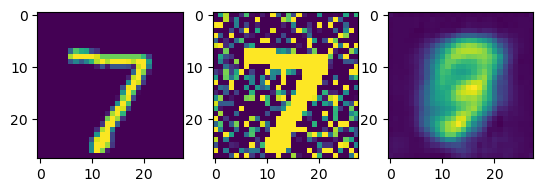

In [82]:
plt.subplot(1,3,1)
plt.imshow(sample)
plt.subplot(1,3,2)
plt.imshow(sample_noise.squeeze(0))
plt.subplot(1,3,3)
plt.imshow(predict)